In [7]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '../src'))

from kamino.planet import planet
from kamino.constants import *
from kamino.seafloor_weathering.weathering import get_k_eff, get_C_eq

import matplotlib.pyplot as plt
import numpy as np

In [14]:
alpha = PORE_DEPTH * (1 - POROSITY) * 2700 * 10

print(f'Reactive area per planet surface area: {alpha:.2e}')

P_pore = 1000 * 10 * 3e3
P_surf = 1e5
q_ref = 0.05

print(f'Seafloor pressure: {P_pore:.2e} Pa')

Reactive area per planet surface area: 2.43e+06
Seafloor pressure: 3.00e+07 Pa


In [18]:
def get_k_therm(P, T, x_CO2, q, alpha):

    C_eq = get_C_eq(P, T, x_CO2)

    return (q * C_eq) / alpha

k_supp = 1 / (0.216 * 100 * 50e6)

print(f'k_eff at supply limit: {k_supp:.2e} mol / m^2 / yr')

k_eff at supply limit: 9.26e-10 mol / m^2 / yr


In [10]:
T_range = np.linspace(274, 340, num=20)
pco2_range = np.logspace(-2, 5, num=20)

k_eff = np.zeros((20, 20))
k_therm = np.zeros((20, 20))

for i, T in enumerate(T_range):
    for j, pco2 in enumerate(pco2_range):
        
        x_CO2 = pco2 / P_surf
        P = float(P_surf / 1e5) # convert to bar
        
        # P = np.clip(P, pr.P.min(), pr.P.max())
        # x_CO2 = np.clip(x_CO2, pr.xCO2.min(), pr.xCO2.max())
        # T = np.clip(T, pr.T.min(), pr.T.max())

        k_therm[j, i] = get_k_therm(P_pore / 1e5, T, x_CO2, q_ref, alpha)
        k_eff[j, i] = get_k_eff(P_pore / 1e5, T, x_CO2)

/tmp/ipykernel_244913/4069925446.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_therm[j, i] = get_k_therm(P_pore / 1e5, T, x_CO2, q_ref, alpha)
/tmp/ipykernel_244913/4069925446.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_eff[j, i] = get_k_eff(P_pore / 1e5, T, x_CO2)


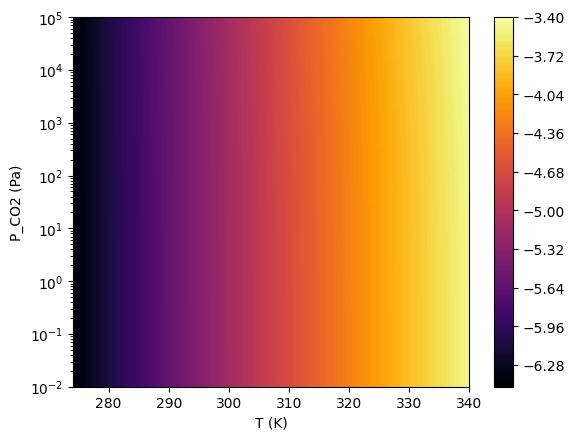

In [19]:
plt.contourf(T_range, pco2_range, np.log10(k_eff), 200, cmap='inferno')
plt.colorbar()
plt.xlabel('T (K)')
plt.ylabel('P_CO2 (Pa)')
plt.yscale('log')
plt.show()

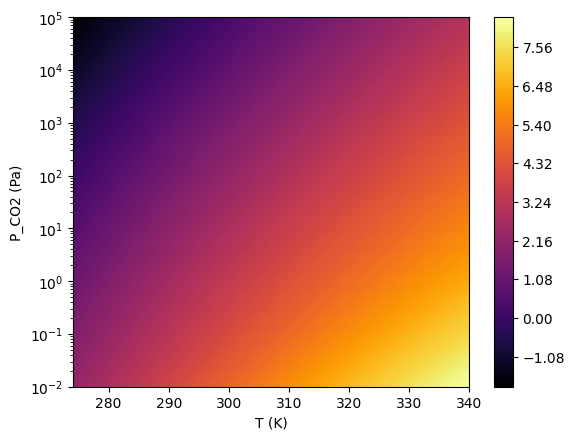

In [15]:
plt.contourf(T_range, pco2_range, np.log10(k_eff / k_therm), 200, cmap='inferno')
plt.colorbar()
plt.xlabel('T (K)')
plt.ylabel('P_CO2 (Pa)')
plt.yscale('log')
plt.show()